**Imports**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import ast
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Bidirectional, Dense, TimeDistributed, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import files
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

train_df = pd.read_csv('Dataset_A_Tag_train.csv')
test_df = pd.read_csv('Dataset_A_Tag_test.csv')


TensorFlow version: 2.18.0
Num GPUs Available: 1


**Tag Data Visualization**

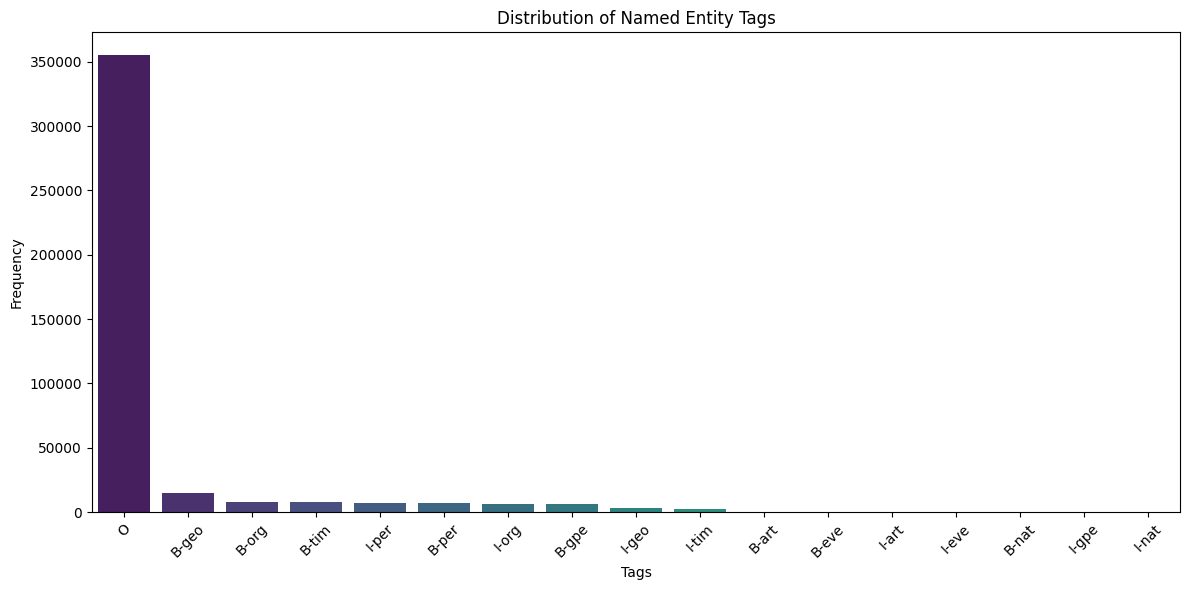

Total unique words in vocab: 22909
Total unique tags: 17


In [ ]:
train_df = pd.read_csv('Dataset_A_Tag_train.csv')
test_df = pd.read_csv('Dataset_A_Tag_test.csv')

# Unique tags
all_tags_flat = [tag for sublist in train_df['Tag'] for tag in ast.literal_eval(sublist)]
tag_counts = pd.Series(all_tags_flat).value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=tag_counts.index, y=tag_counts.values, hue=tag_counts.index, palette='viridis', legend=False)
plt.title("Distribution of Named Entity Tags")
plt.xlabel("Tags")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Total unique words in vocab:", len(set(word for s in train_df['Sentence'] for word in s.split())))
print("Total unique tags:", len(tag_counts))


Train & Test Set Split and Modification

In [ ]:
train_df['Tag'] = train_df['Tag'].apply(ast.literal_eval)
test_df['Tag'] = test_df['Tag'].apply(ast.literal_eval)

train_sentences = train_df['Sentence'].apply(str.split).tolist()
train_tags = train_df['Tag'].tolist()

test_sentences = test_df['Sentence'].apply(str.split).tolist()
test_tags = test_df['Tag'].tolist()


In [ ]:
tokenizer = Tokenizer(oov_token='UNK')
tokenizer.fit_on_texts(train_sentences + test_sentences)
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

X_train = tokenizer.texts_to_sequences(train_sentences)
X_test = tokenizer.texts_to_sequences(test_sentences)
print(X_train[0])
max_len = max(max(len(s) for s in X_train), max(len(s) for s in X_test))
X_train = pad_sequences(X_train, padding='post', maxlen=max_len)
X_test = pad_sequences(X_test, padding='post', maxlen=max_len)

[1672, 36, 282, 2596, 203, 97, 4, 43, 3844, 5, 685, 853, 7, 295, 345, 9, 2, 164, 7, 2, 132, 63, 260, 3]


In [ ]:
all_tags = list(set(tag for row in train_tags for tag in row))
tag2idx = {tag: i for i, tag in enumerate(all_tags)}



y_train = [[tag2idx[tag] for tag in row] for row in train_tags]
y_test = [[tag2idx.get(tag, 0) for tag in row] for row in test_tags]

y_train = pad_sequences(y_train, padding='post', maxlen=max_len)
y_test = pad_sequences(y_test, padding='post', maxlen=max_len)


y_train = to_categorical(y_train, num_classes=len(tag2idx))
y_test = to_categorical(y_test, num_classes=len(tag2idx))

Model Build

In [ ]:
def build_model(cell, bidirectional=False):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
    model.add(Dropout(0.3))
    if bidirectional:
        model.add(Bidirectional(cell(64, return_sequences=True)))
    else:
        model.add(cell(64, return_sequences=True))

    model.add(Dropout(0.3))
    model.add(TimeDistributed(Dense(len(tag2idx), activation='softmax')))
    adam = Adam(learning_rate=0.001)
    model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

models = {
    'RNN': build_model(SimpleRNN),
    'LSTM': build_model(LSTM),
    'GRU': build_model(GRU),
    'BiLSTM': build_model(LSTM, bidirectional=True)
}

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model Fit

\nTraining RNN...
Epoch 1/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.9338 - loss: 0.3403 - val_accuracy: 0.9871 - val_loss: 0.0533
Epoch 2/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.9876 - loss: 0.0494 - val_accuracy: 0.9898 - val_loss: 0.0367
Epoch 3/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9907 - loss: 0.0334 - val_accuracy: 0.9902 - val_loss: 0.0340
Epoch 4/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9922 - loss: 0.0268 - val_accuracy: 0.9904 - val_loss: 0.0331
Epoch 5/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9933 - loss: 0.0228 - val_accuracy: 0.9902 - val_loss: 0.0342
Epoch 6/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9939 - loss: 0.0198 - val_accuracy: 0.9899 - val_loss: 0.0364
Epoch 7/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9945 - loss: 0.0177 - val_accuracy: 0.9896 - val_loss: 0.0375
Epoch 8/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9950 - l

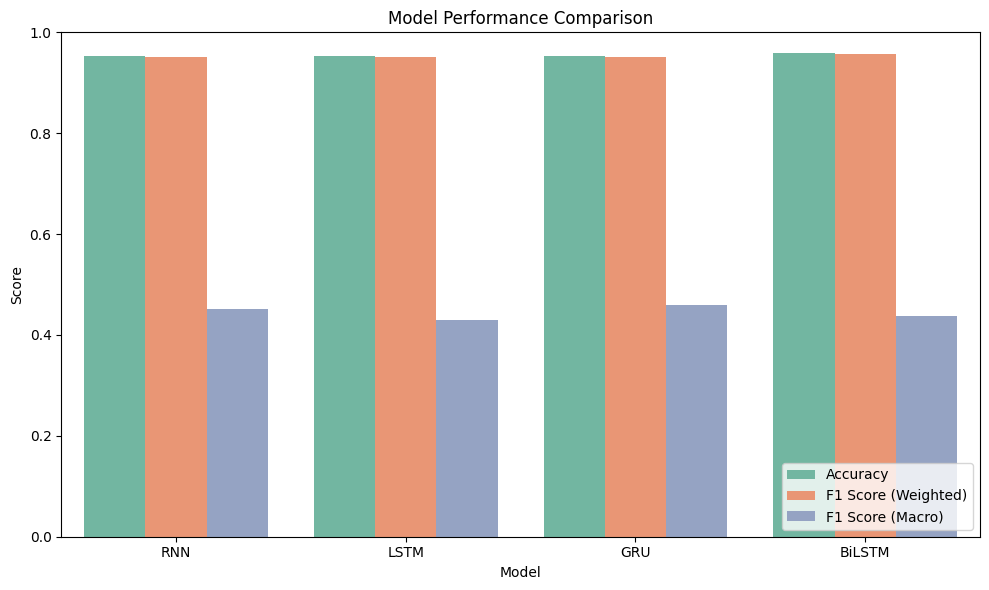

In [ ]:
results = []
for name, model in models.items():
    with tf.device('/GPU:0'):
      print(f"\\nTraining {name}...")
      early_stop = EarlyStopping(
      monitor='val_loss',      #'val_accuracy'
      patience=5,
      restore_best_weights=True
      )
      model.fit(X_train, y_train, batch_size=32, epochs=20, validation_split=0.1,callbacks=[early_stop],verbose=1)

      print(f"\\nEvaluating {name}...")
      y_pred = model.predict(X_test, verbose=0)
      y_pred_labels = np.argmax(y_pred, axis=-1)
      y_true_labels = np.argmax(y_test, axis=-1)

      all_true, all_pred = [], []
      for true_seq, pred_seq in zip(y_true_labels, y_pred_labels):
          for t, p in zip(true_seq, pred_seq):
              if t != 0:
                  all_true.append(t)
                  all_pred.append(p)
      acc = accuracy_score(all_true, all_pred)
      f1_weighted = f1_score(all_true, all_pred, average='weighted')
      f1_macro = f1_score(all_true, all_pred, average='macro')
      results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score (Weighted)": f1_weighted,
        "F1 Score (Macro)": f1_macro
      })

      print(f"Accuracy for {name}:", acc)
      print(f"F1 Score (weighted) for {name}:", f1_weighted)
      print(f"F1 Score (macro) for {name}:", f1_macro)
      print(f"Classification Report for {name}:")
      print(classification_report(all_true, all_pred, labels=list(tag2idx.values()), target_names=list(tag2idx.keys()), zero_division=0))
      print("Confusion Matrix:")
      print(confusion_matrix(all_true, all_pred))
results_df = pd.DataFrame(results)
print(results_df)
plt.figure(figsize=(10,6))
sns.barplot(data=results_df.melt(id_vars='Model', var_name='Metric', value_name='Score'),
            x='Model', y='Score', hue='Metric', palette='Set2')
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
